In [173]:
import sympy as sp
import numpy as np
import scienceplots 
import matplotlib.pyplot as plt

plt.style.use(["science","no-latex"])

In [174]:
# Define symbols
t = sp.symbols('t', real=True)
zeta, wn,z = sp.symbols('zeta wn z', positive=True)
y = sp.Function('y')

In [175]:
# Define the ODE
ode = sp.Eq(
    y(t).diff(t, 2)
    + 2*zeta*wn*y(t).diff(t)
    + wn**2*y(t),
    wn**2
)

ode

Eq(wn**2*y(t) + 2*wn*zeta*Derivative(y(t), t) + Derivative(y(t), (t, 2)), wn**2)

In [176]:
def calc_ode(ode):
    solution = sp.dsolve(
        ode,
        ics={
            y(0): 0,
            y(t).diff(t).subs(t, 0): 0
        }
    )
    return solution

In [177]:
def get_response(zeta_value,ode):
    t_values=np.linspace(0,10,1000)
    solution_expr=calc_ode(ode.subs(wn,1).subs(zeta,zeta_value)).rhs
    func=sp.lambdify(t,solution_expr,modules=["numpy"])
    response=func(t_values)
    return response,t_values

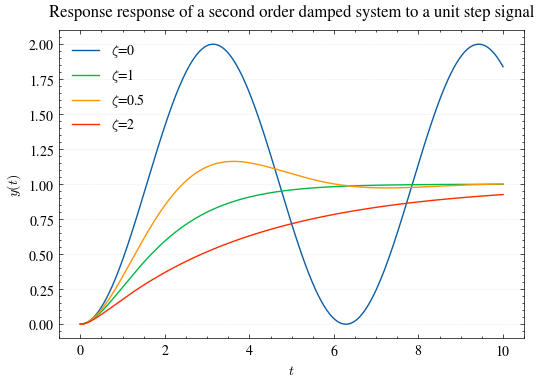

In [192]:
#plotting the function 
zeta_values=[0,1,0.5,2]
fig=plt.figure(figsize=(6,4))
for zeta_value in zeta_values:
    response,t_values=get_response(zeta_value,ode)
    plt.plot(t_values,response,label=f"$\zeta$={zeta_value}")
plt.legend()
plt.grid(True,alpha=0.2,axis='y',linestyle="--")
plt.title("Response response of a second order damped system to a unit step signal",fontsize=12,pad=10)
plt.ylabel("$y(t)$")
plt.xlabel("$t$")
plt.savefig("plot")
plt.show()
